# Plot the different configurations of SOM

- 1. Independent HFR 
    - a) Solo Coffs Harbour
    - b) Solo Newcastle 

- 2. Solo HFR + Temperature or Chl

- 3. Both HFR together

In [2]:
import warnings
get_ipython().run_line_magic('run', '"/media/nbourg/One Touch/PhD/Separation_HFR_EAC/toolbox.ipynb"')
warnings.filterwarnings('ignore')

## Data & Packages

In [18]:
#------------------------------------------------------
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from xpysom import XPySom
from datetime import datetime

import cartopy.feature as cfeature
import cartopy.crs as ccrs
#------------------------------------------------------

git = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/'

path_data = git+'Data/'
coffs = xr.open_dataset(path_data+'HFR/Vectors_Filled/currents_dineof_COFFS_Y2019M07_Y2020M12.nc')
newc = xr.open_dataset(path_data+'HFR/Vectors_Filled/currents_dineof_NEWC_Y2019M07_Y2021M12.nc')

alti_path = git+'Data/Altimetry/'
file_u = xr.open_dataset(alti_path+'altimetry_eac_2019_2021_eac_U.nc')
file_v = xr.open_dataset(alti_path+'altimetry_eac_2019_2021_eac_V.nc')


u_sat = file_u['ugos'].values[181:,:,6:30]
v_sat = file_v['vgos'].values[181:,:,6:30]
lon_f = file_u['longitude'].values[6:30]
lat_f = file_u['latitude'].values
lon_sat,lat_sat = np.meshgrid(lon_f, lat_f)
del lon_f,lat_f

path_fig = git+'Analysis/Self_Organizing_Maps/SOM_Different_Tests/figs/'
path_save_soms = git+'Analysis/Self_Organizing_Maps/SOM_Different_Tests/saved_soms/'

## Functions

In [27]:
def load_som_only_radar(name,file):
    
    data = np.load(path_save_soms+name+'.npz',allow_pickle=True)
    som = data['som']
    neuron_u = data['neuron_u']
    neuron_v = data['neuron_v']
    
    bmus = np.nan*np.zeros(file['time'].values.shape)
    bmus[~np.isnan(np.nanmean(file['u'],axis=(1,2)))] = data['bmus']
    
    return som, neuron_u, neuron_v, bmus

#-----------------------------------------------------------------------------

def plot_som_only_radar(lon,lat,neuron_u,neuron_v,step,name):
    

    cols = neuron_u.shape[0]
    rows = neuron_u.shape[1]
    
    fig = plt.figure(figsize=(14,14))

    count=1
    for i in range(cols):
        for j in range(rows):
            
            ax = fig.add_subplot(cols, rows, count, projection=ccrs.PlateCarree())
            count=count+1
            ax.quiver(lon[::step,::step],
                            lat[::step,::step],
                            neuron_u[i,j,::step,::step],
                            neuron_v[i,j,::step,::step],scale=5,color='k')
            
            

            gl = ax.gridlines(draw_labels=True,zorder=0)
            ax.add_feature(cfeature.LAND,zorder=1)
            ax.add_feature(cfeature.COASTLINE,zorder=2)
            gl.top_labels = gl.right_labels = False
            if i<2:
                gl.bottom_labels=False
            if j>0:
                gl.left_labels=False
                
    fig.savefig(path_fig+'neurons_'+name+'.png',dpi=500)

    return fig,fig.get_axes()

#-----------------------------------------------------------------------------

def plot_bmu_altimetry(winners, u, v, lon, lat, hfr_file,cols,rows,name):

    s_t = len(hfr_file['time'].values)

    ub = u[:s_t,:,:]
    vb = v[:s_t,:,:]
    
    neurs = np.arange(0,cols*rows).reshape((cols,rows))
    
    fig = plt.figure(figsize=(14,14))

    for i in range(0,cols):
        for j in range(0,rows):
            freq = int(np.round(100*len(winners[winners==neurs[i][j]])/len(winners)))

            ax = fig.add_subplot(cols, rows, neurs[i][j]+1, projection=ccrs.PlateCarree())

            gl = ax.gridlines(draw_labels=True,zorder=0)
            ax.add_feature(cfeature.LAND,zorder=1)
            ax.add_feature(cfeature.COASTLINE,zorder=2)
            gl.top_labels = gl.right_labels = False
            if i<2:
                gl.bottom_labels=False
            if j>0:
                gl.left_labels=False
                
            neuron = neurs[i][j]
            u_alti_neu = np.nanmean(ub[winners==neuron],axis=0)
            v_alti_neu = np.nanmean(vb[winners==neuron],axis=0)

            ax.quiver(lon, lat, u_alti_neu, v_alti_neu, scale=7,zorder=5,color='k')
            ax.set_ylim(-37.5,-27.5)
            


            # these are matplotlib.patch.Patch properties
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            str_box = 'N'+str(neurs[i][j]+1)+' : '+str(freq)+' %'
            # place a text box in upper left in axes coords
            ax.text(0.05, 0.985, str_box, transform=ax.transAxes, fontsize=14,
                    verticalalignment='top', bbox=props)
    fig.savefig(path_fig+'bmus_altimetry_'+name+'.png',dpi=500)
    return fig, fig.get_axes()

## Configs 1A & 1B

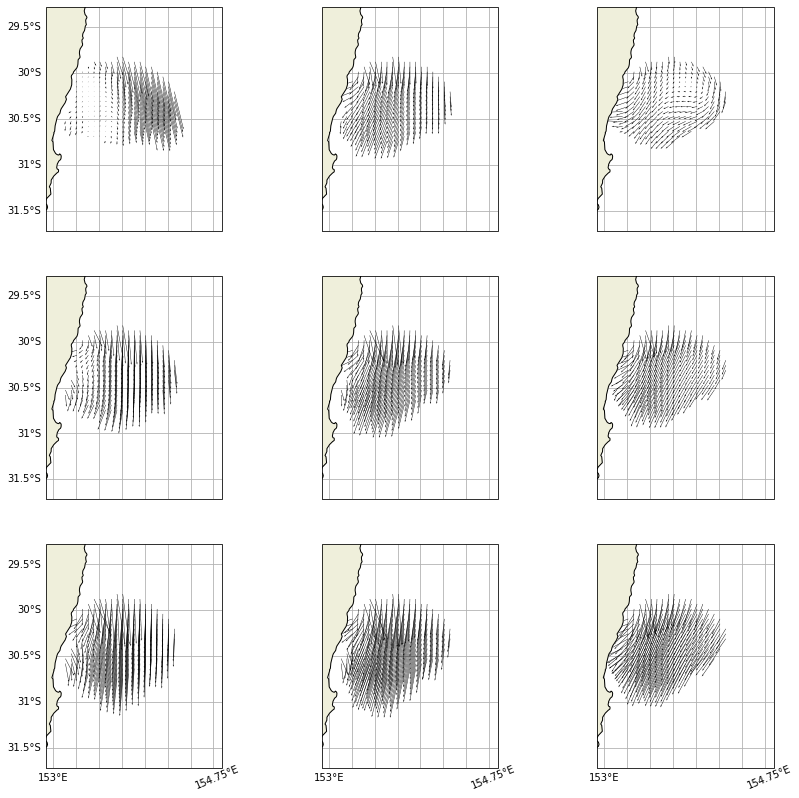

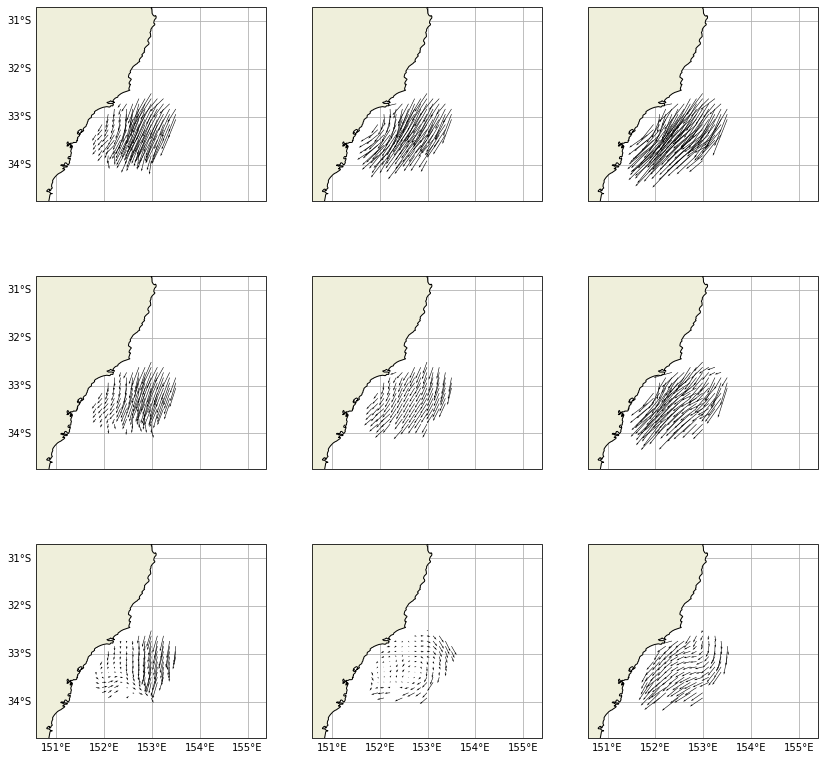

In [49]:

[som1b, neuron_u1b, neuron_v1b, bmus1b] = load_som_only_radar(name='coffs_only',file=coffs)

fig,axs=plot_som_only_radar(coffs['lon'].values,
                            coffs['lat'].values,
                            neuron_u1b,
                            neuron_v1b, step=4,name='coffs')

[som1a, neuron_u1a, neuron_v1a, bmus1a] = load_som_only_radar(name='newcastle_only',file=newc)

fig,axs=plot_som_only_radar(newc['lon'].values,newc['lat'].values,neuron_u1a,neuron_v1a, 2, 'newc')


Text(0.5, 0.98, 'Altimetry from Coffs')

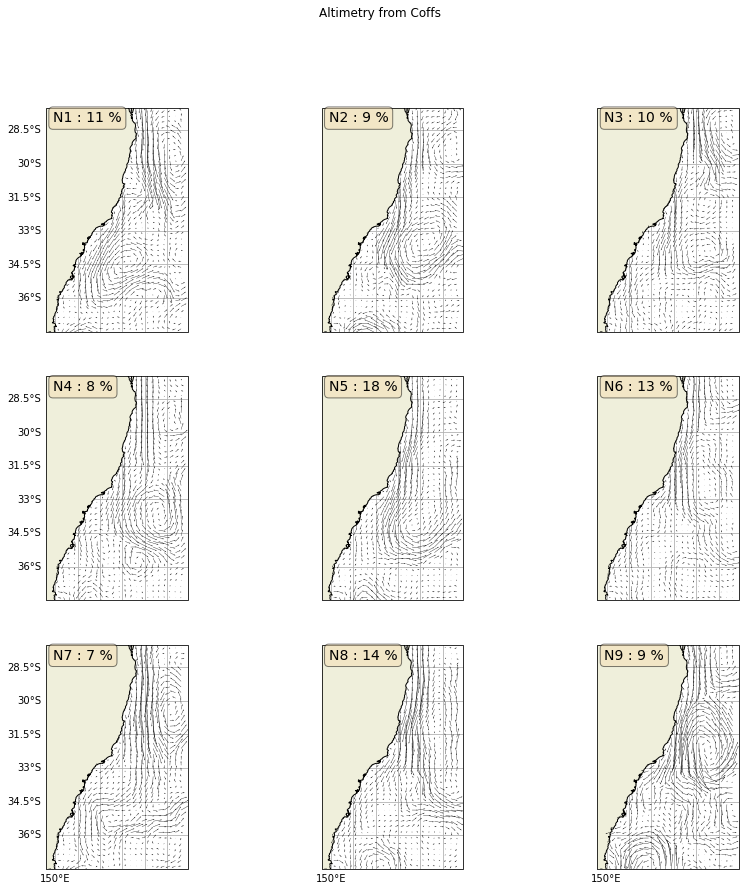

In [28]:

fig,axs=plot_bmu_altimetry(bmus1b, 
                           u_sat, 
                           v_sat,
                           lon_sat,
                           lat_sat,
                           coffs,cols=3,rows=3,name='coffs')
fig.suptitle('Altimetry from Coffs')

Text(0.5, 0.98, 'Altimetry from Newcastle')

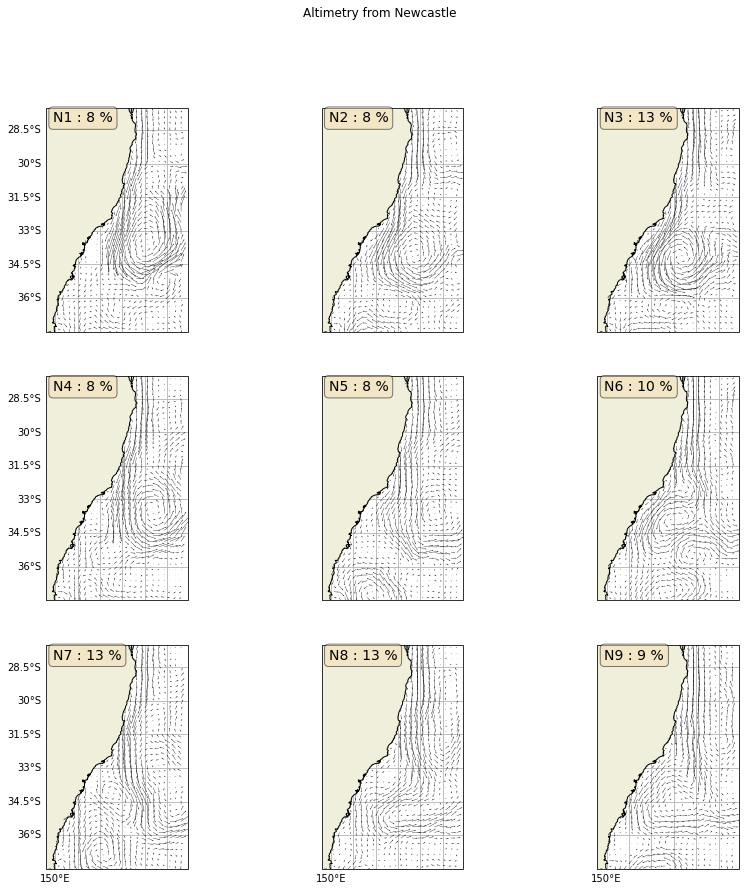

In [29]:
fig,axs=plot_bmu_altimetry(bmus1a, 
                           u_sat, 
                           v_sat,
                           lon_sat,
                           lat_sat,
                           newc,cols=3,rows=3,name='newc')
fig.suptitle('Altimetry from Newcastle')

## Comparing the two outputs of 1A and 1B
When looking at the BMUs of altimetry data from two different clusterings (Coffs alone, and Newc alone). We see that a lot of neurons exhibit very similar large scale patterns. Also, when looking at the histograms of some very similar (spatial patterns wise) neurons, it can be hard to tell if they occur at the same timing or not, but for some of them it seems to match really well (e.g. orange). So, it sounds interesting to put everything together, also itwould be much easier for the analysis to just do all together.

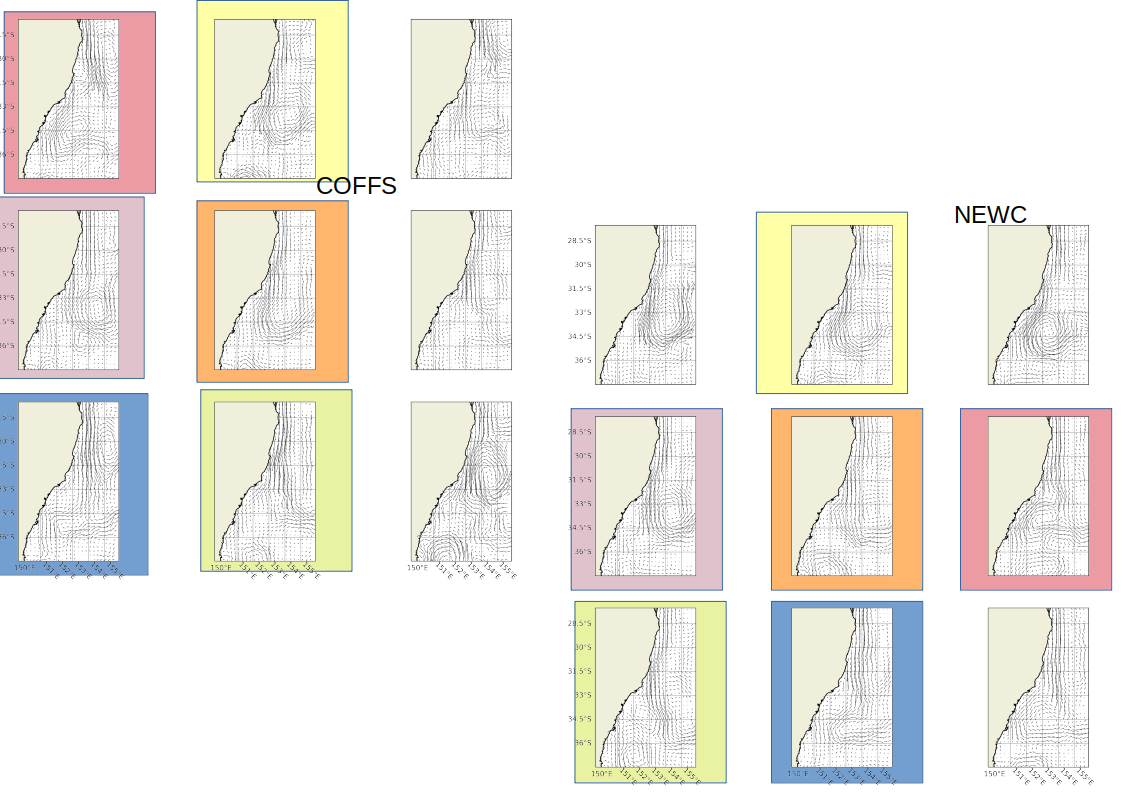

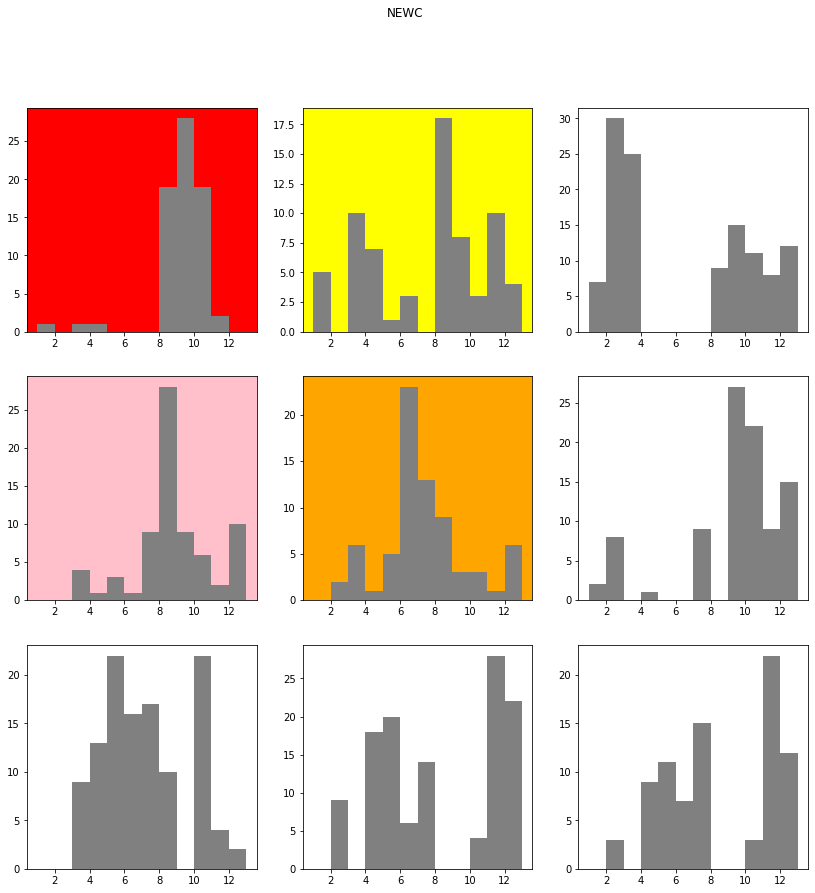

In [48]:
months=pd.to_datetime(newc['time'].values).month
fig = plt.figure(figsize=(14,14))
cols=3
rows=3
count=1
neurs = np.arange(0,cols*rows).reshape((cols,rows))
fig.suptitle('NEWC')
for i in range(cols):
    for j in range(rows):
        ax = fig.add_subplot(cols, rows, neurs[i][j]+1)
        ax.hist(months[bmus1a==neurs[i][j]],
               bins=[1,2,3,4,5,6,7,8,9,10,11,12,13],color='gray')
axs=fig.get_axes()
axs[0].set_facecolor('red')

axs[1].set_facecolor('yellow')
axs[3].set_facecolor('pink')
axs[4].set_facecolor('orange')

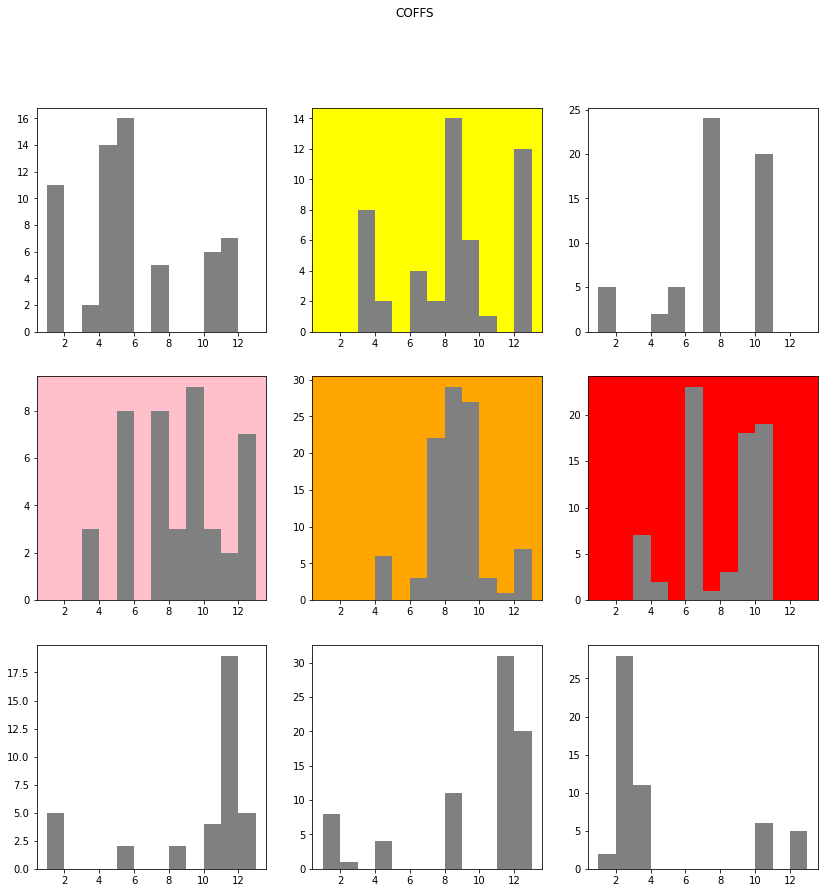

In [47]:

months=pd.to_datetime(coffs['time'].values).month
fig = plt.figure(figsize=(14,14))
cols=3
rows=3
count=1
neurs = np.arange(0,cols*rows).reshape((cols,rows))
fig.suptitle('COFFS')

for i in range(cols):
    for j in range(rows):
        ax = fig.add_subplot(cols, rows, neurs[i][j]+1)
        ax.hist(months[bmus1b==neurs[i][j]],
               bins=[1,2,3,4,5,6,7,8,9,10,11,12,13],color='gray')

axs=fig.get_axes()
axs[1].set_facecolor('yellow')
axs[3].set_facecolor('pink')
axs[4].set_facecolor('orange')
axs[5].set_facecolor('red')
